In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

In [3]:
# Config / Hyperparameters
DATA_DIR = '/kaggle/working/data'   
NUM_CLASSES = 100
BATCH_SIZE = 128        
NUM_EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
MOMENTUM = 0.9
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_DATAPARALLEL = torch.cuda.device_count() > 1
PIN_MEMORY = True
NUM_WORKERS = 4

print("Device:", DEVICE)
print("GPUs available:", torch.cuda.device_count())
print("Using DataParallel:", USE_DATAPARALLEL)

Device: cuda
GPUs available: 2
Using DataParallel: True


In [4]:
# Data transforms
# Inception expects 299x299 images. Pretrained model uses ImageNet normalization.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.02),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

test_transform = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [5]:
# Datasets and Dataloaders
os.makedirs(DATA_DIR, exist_ok=True)

train_dataset = datasets.CIFAR100(root=DATA_DIR, train=True, download=True, transform=train_transform)
test_dataset  = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Train samples:", len(train_dataset), "| Test samples:", len(test_dataset))

100%|██████████| 169M/169M [00:01<00:00, 90.8MB/s] 


Train samples: 50000 | Test samples: 10000


In [6]:
# Model: transfer learning with inception_v3
def create_model(num_classes=100, pretrained=True, aux_logits=True, freeze_backbone=False):
    # torchvision's inception_v3 returns aux_logits during training
    model = models.inception_v3(pretrained=pretrained, aux_logits=aux_logits)
    # Replace the main classifier
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    # Replace the aux classifier as well (if aux_logits True)
    if aux_logits:
        aux_in = model.AuxLogits.fc.in_features
        model.AuxLogits.fc = nn.Linear(aux_in, num_classes)
    # Optionally freeze backbone (except final fc and aux)
    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'fc' not in name and 'AuxLogits' not in name:
                param.requires_grad = False
    return model

model = create_model(num_classes=NUM_CLASSES, pretrained=True, aux_logits=True, freeze_backbone=False)
model = model.to(DEVICE)

if USE_DATAPARALLEL:
    # Simple multi-GPU: DataParallel
    model = nn.DataParallel(model)
    print("Wrapped model with DataParallel")

# Print a summary of number of parameters and trainable params
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}, Trainable params: {trainable_params:,}")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 187MB/s]  


Wrapped model with DataParallel
Total params: 24,625,064, Trainable params: 24,625,064


In [7]:
# Loss, optimizer, scheduler

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [8]:
# Training & Evaluation loops
scaler = torch.cuda.amp.GradScaler()  # for mixed precision

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    num_samples = 0

    pbar = tqdm(dataloader, desc=f"Train Epoch {epoch}", leave=False)
    for inputs, labels in pbar:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        # Inception returns outputs, aux_outputs when model is in training and aux_logits=True
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            if isinstance(outputs, tuple):  # if DataParallel, inception returns tuple
                # torchvision's inception_v3 returns (logits, aux_logits) in training mode
                logits, aux_logits = outputs[0], outputs[1]
            else:
                # If model isn't returning tuple, it may be wrapped differently; handle general case
                # Many wrappers return logits directly and ignore aux during eval
                logits = outputs
                aux_logits = None

            loss = criterion(logits, labels)
            # add aux logits loss if present
            if aux_logits is not None:
                loss_aux = criterion(aux_logits, labels)
                loss = loss + 0.4 * loss_aux  # standard weighting for inception

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # stats
        bs = inputs.size(0)
        running_loss += loss.item() * bs
        _, preds = torch.max(logits, 1)
        running_corrects += torch.sum(preds == labels).item()
        num_samples += bs

        pbar.set_postfix(loss=running_loss / num_samples, acc=running_corrects / num_samples)

    epoch_loss = running_loss / num_samples
    epoch_acc = running_corrects / num_samples
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, dataloader, criterion, device, epoch):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    num_samples = 0

    pbar = tqdm(dataloader, desc=f"Eval Epoch {epoch}", leave=False)
    for inputs, labels in pbar:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            # if outputs is tuple (DataParallel/inception) pick first
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            loss = criterion(logits, labels)

        bs = inputs.size(0)
        running_loss += loss.item() * bs
        _, preds = torch.max(logits, 1)
        running_corrects += torch.sum(preds == labels).item()
        num_samples += bs

        pbar.set_postfix(val_loss=running_loss / num_samples, val_acc=running_corrects / num_samples)

    epoch_loss = running_loss / num_samples
    epoch_acc = running_corrects / num_samples
    return epoch_loss, epoch_acc


/tmp/ipykernel_36/1955088365.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # for mixed precision


In [9]:
# Training

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

start_time = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, epoch)
    val_loss, val_acc = evaluate(model, test_loader, criterion, DEVICE, epoch)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} | Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

    # deep copy the best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model_wts,
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc,
        }, 'Inception-v3.pt')
        print(f"Saved new best model with val_acc={best_acc:.4f}")

total_time = time.time() - start_time
print(f"Training complete in {total_time//60:.0f}m {total_time%60:.0f}s. Best val Acc: {best_acc:.4f}")

# load best model weights
model.load_state_dict(best_model_wts)

Train Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]/tmp/ipykernel_36/1955088365.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval Epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]                                    /tmp/ipykernel_36/1955088365.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01 | Train Loss 2.7741 Acc 0.4585 | Val Loss 1.5472 Acc 0.5668
Saved new best model with val_acc=0.5668


Epoch 02 | Train Loss 1.7446 Acc 0.6331 | Val Loss 1.1952 Acc 0.6604
Saved new best model with val_acc=0.6604


Epoch 03 | Train Loss 1.3645 Acc 0.7078 | Val Loss 1.0246 Acc 0.7079
Saved new best model with val_acc=0.7079


Epoch 04 | Train Loss 1.1342 Acc 0.7512 | Val Loss 0.9880 Acc 0.7236
Saved new best model with val_acc=0.7236


...

Epoch 27 | Train Loss 0.0093 Acc 0.9983 | Val Loss 0.8668 Acc 0.8329


Epoch 28 | Train Loss 0.0083 Acc 0.9988 | Val Loss 0.8568 Acc 0.8353
Saved new best model with val_acc=0.8353


Epoch 29 | Train Loss 0.0078 Acc 0.9988 | Val Loss 0.8511 Acc 0.8346


Epoch 30 | Train Loss 0.0080 Acc 0.9986 | Val Loss 0.8547 Acc 0.8350
Training complete in 186m 26s. Best val Acc: 0.8353


<All keys matched successfully>

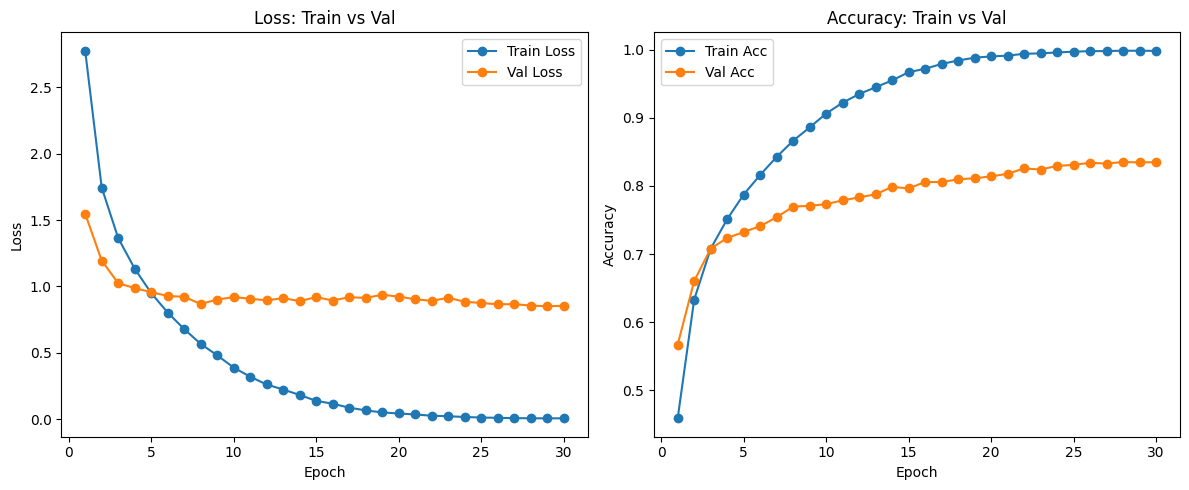

In [14]:
# Plotting: train vs val loss & accuracy

epochs = np.arange(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
plt.plot(epochs, history['val_loss'], marker='o', label='Val Loss')
plt.title('Loss: Train vs Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history['train_acc'], marker='o', label='Train Acc')
plt.plot(epochs, history['val_acc'], marker='o', label='Val Acc')
plt.title('Accuracy: Train vs Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('train_val_curves.png', dpi=200)
plt.show()

In [15]:
# Final evaluation on test set (single pass)
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE, 'Final')
print(f"Final Test Loss: {test_loss:.4f} | Final Test Acc: {test_acc:.4f}")

# Save final model (optional)
torch.save({'model_state_dict': model.state_dict()}, 'Inception-V3.pt')
print("Saved final model to Inception-V3.pt")

Eval Epoch Final:   0%|          | 0/79 [00:00<?, ?it/s]/tmp/ipykernel_36/1955088365.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Final Test Loss: 0.8568 | Final Test Acc: 0.8353
Saved final model to Inception-V3.pt
